# Import and inputs

In [116]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = str(Path("../..").resolve())
case_study_root = str(Path(".").resolve())
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
import re

from merge_formula import nominal_merge_formula, verbal_merge_formula
from SynFlow.Explorer import (
    build_sfiller_df,
    compute_saturating_support_from_sfiller_df,
    merge_sfiller_df_columns,
    spath_explorer,
    spaths_json_to_slotfiller_df,
    rel_explorer,
)
from SynFlow.Explorer.sfiller_df import get_all_slots
from SynFlow.SCD import (
    compute_consecutive_dist_df,
    compute_weighted_consecutive_dist_df,
    count_keyword_tokens_by_period,
    compute_period_period_dist,
    freq_all_slots_by_period,
    multiply_consecutive_dist_saturating_support,
    permutation_test_consecutive_dist,
    plot_all_dists_by_period,
    plot_freq_top_union_slots_by_period,
    plot_period_period_dist,
    plot_permutation_test_consecutive_dist,
    summarize_fdr_correction,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
# Specify required input

# Input target
target_lemma = "float"
target_pos = "ALLPOS" # Your specific POS or ALLPOS

# Period and regex pattern of the SynFlow parsed file
period = "1810-2000"
corpus_pattern = re.compile(
    r"([^\t]+)\t"      # SRL component
    r"([^\t]+)\t"      # lemmatised SRL component
    r"([^\t]+)\t"      # placeholder
    r"([^\t]+)\t"      # ID
    r"([^\t]+)\t"      # HEAD
    r"([^\t]+)\t"      # SRL
    r"([^\t]+)"        # placeholder
)

# Specify corpus and output folders
corpus_folder = f"/home/volt/bach/pilot_data/float_gen_srl"
output_folder = Path(".").resolve()

# The path to the SRL count JSON file
SRL_json_path = f"output/{target_lemma}_{target_pos}_{period}/Explorer/SRL/{target_lemma}_{target_pos}_spaths.json"


In [118]:
# Dont change below this line
output_folder_lemma = output_folder / "output" / f"{target_lemma}_{target_pos}_{period}"
output_explorer = f"{output_folder_lemma}/Explorer/SRL"
output_embedding = f"{output_folder_lemma}/Embedding/SRL"
input_SCD = output_folder / "input" /f"{target_lemma}_{target_pos}_{period}" / "SCD" / "SRL"
output_SCD = output_folder / "output" /f"{target_lemma}_{target_pos}_{period}" / "SCD" / "SRL"

os.makedirs(output_explorer, exist_ok=True)
os.makedirs(output_embedding, exist_ok=True)
os.makedirs(input_SCD, exist_ok=True)
os.makedirs(output_SCD, exist_ok=True)

# Explore the distribution of the SRL components
* For DEMO, go straight to the calculating-weighted-distance section

## SRL Frequencies

[1990] Collected 811 context links, 17 distinct arguments.


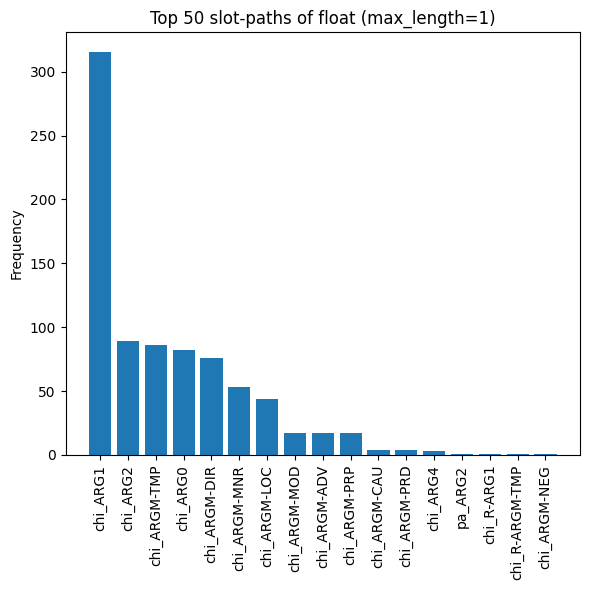

[2000] Collected 811 context links, 17 distinct arguments.


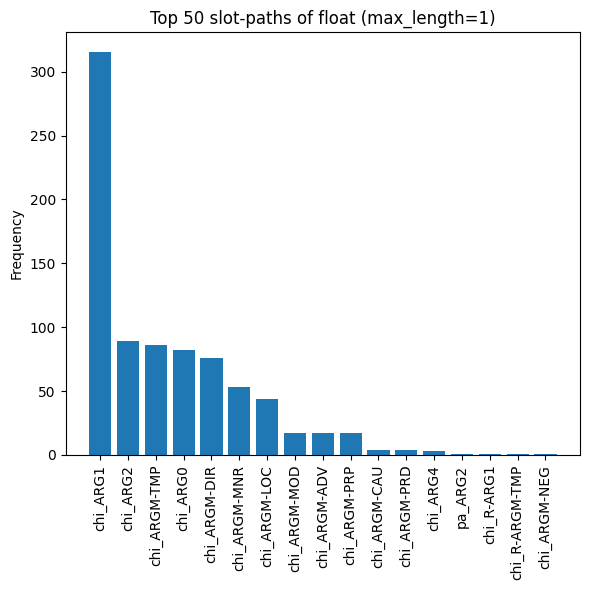

Saved slot-path frequencies to: /home/volt/bach/SynFlow/case_studies/SynFlow-test/output/float_ALLPOS_1810-2000/Explorer/SRL/float_ALLPOS_spaths.json


In [119]:
dist = spath_explorer(
    corpus_folder=corpus_folder,
    target_lemma=target_lemma,
    target_pos=target_pos,
    max_length=1,
    top_n=50,
    pattern=corpus_pattern,
    output_folder=output_explorer
)

In [120]:
# Token counts for normalisation
token_counts = count_keyword_tokens_by_period(corpus_folder, target_lemma, target_pos,
                                              max_workers=64)
print(token_counts)


{'1990': 299, '2000': 299}


In [121]:
plot_freq_top_union_slots_by_period(
    json_path=SRL_json_path,
    top_n=10,
    normalized=True,
    relative=False,
    token_counts=token_counts,
)


In [122]:
SRL_raw_freq_df = freq_all_slots_by_period(json_path=SRL_json_path).T
SRL_raw_freq_df.head(30)

,1990,2000
chi_ARG1,315.0,315.0
chi_ARG2,89.0,89.0
chi_ARGM-TMP,86.0,86.0
chi_ARG0,82.0,82.0
chi_ARGM-DIR,76.0,76.0
chi_ARGM-MNR,53.0,53.0
chi_ARGM-LOC,44.0,44.0
chi_ARGM-MOD,17.0,17.0
chi_ARGM-ADV,17.0,17.0
chi_ARGM-PRP,17.0,17.0


## Rel Explorer
* You can explore what the SRLs mean here

In [123]:

rel_single_path_results = rel_explorer(
    corpus_folder=corpus_folder,
    pattern=corpus_pattern,
    target_lemma=target_lemma,
    target_pos=target_pos,
    deprel="> (chi_ARG2, [])",
    filler_format="lemma/deprel", # lemma_only, lemma/pos, lemma/deprel, token_only, token/pos, token/deprel
    # Single-path searches always use open matching.
)

rel_single_path_results


,sentence_id,sentence,sfillers,path
0,1990_300_float_verb_sentences_1_1,Dry wood will easily float on water,[on water/chi_ARG2],chi_ARG2
1,1990_300_float_verb_sentences_2_1,Oil float above water because of its lower den...,[above water/chi_ARG2],chi_ARG2
2,1990_300_float_verb_sentences_4_1,The empty plastic bottle floated downstream af...,[downstream/chi_ARG2],chi_ARG2
3,1990_300_float_verb_sentences_6_1,A single red petal floated across the surface ...,[across the surface of the pond/chi_ARG2],chi_ARG2
4,1990_300_float_verb_sentences_8_1,The wreckage from the ship float near the coas...,[near the coastline/chi_ARG2],chi_ARG2
...,...,...,...,...
173,2000_300_float_verb_sentences_291_1,A faint scent of citrus floated from the fresh...,[from the freshly clean counter/chi_ARG2],chi_ARG2
174,2000_300_float_verb_sentences_293_1,The soap suds float on the surface of the wash...,[on the surface of the washbasin/chi_ARG2],chi_ARG2
175,2000_300_float_verb_sentences_294_2,The company float on the domestic exchange bef...,[on the domestic exchange/chi_ARG2],chi_ARG2
176,2000_300_float_verb_sentences_297_1,Floating seeds float on the breeze to colonize...,[on the breeze/chi_ARG2],chi_ARG2


In [124]:
out_path = f"{output_explorer}/rel_1_path_explorer.tsv"
rel_single_path_results.to_csv(out_path, sep="\t", index=False)


# Build SRL df of all SRLs

In [125]:
SRL_type_df = spaths_json_to_slotfiller_df(json_path=SRL_json_path,
                                    #    exclude=["chi_ARG1", "chi_ARG2"]
                                       )

print(SRL_type_df.head(10))
SRL_type_df.to_csv(f"{input_SCD}/{target_lemma}_{target_pos}_SRL_type_df.csv", index=False)

        id subfolder             target           type
0   1990_1      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
1   1990_2      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
2   1990_3      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
3   1990_4      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
4   1990_5      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
5   1990_6      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
6   1990_7      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
7   1990_8      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
8   1990_9      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]
9  1990_10      1990  [(float_ALLPOS,)]  [(chi_ARG1,)]


# Build SRLfiller df of all SRLs

In [126]:
# Get all SRLs in the correct format
all_SRLs = get_all_slots(SRL_raw_freq_df)
print(all_SRLs)

[chi_ARG1][chi_ARG2][chi_ARGM-TMP][chi_ARG0][chi_ARGM-DIR][chi_ARGM-MNR][chi_ARGM-LOC][chi_ARGM-MOD][chi_ARGM-ADV][chi_ARGM-PRP][chi_ARGM-CAU][chi_ARGM-PRD][chi_ARG4][pa_ARG2][chi_R-ARG1][chi_R-ARGM-TMP][chi_ARGM-NEG]


In [127]:
# Building an SRL filler df

SRLfiller_df, dropped_list = build_sfiller_df(
    corpus_folder=corpus_folder,
    template=all_SRLs, 
    target_lemma=target_lemma,
    target_pos=target_pos,
    pattern=corpus_pattern,
    filtered_pos=[],
    filler_format="token_only", # lemma_only, lemma/deprel, lemma/pos, token_only, token/deprel, token/pos
)


In [128]:
SRLfiller_df

,subfolder,target,chi_ARG1,chi_ARG2,chi_ARGM-TMP,chi_ARG0,chi_ARGM-DIR,chi_ARGM-MNR,chi_ARGM-LOC,chi_ARGM-MOD,chi_ARGM-ADV,chi_ARGM-PRP,chi_ARGM-CAU,chi_ARGM-PRD,chi_ARG4,pa_ARG2,chi_R-ARG1,chi_R-ARGM-TMP,chi_ARGM-NEG
id,,,,,,,,,,,,,,,,,,,
float/300_float_verb_sentences.txt/5,1990,"[(float/ALLPOS,)]","[(Dry wood,)]","[(on water,)]",[],[],[],"[(easily,)]",[],"[(will,)]",[],[],[],[],[],[],[],[],[]
float/300_float_verb_sentences.txt/10,1990,"[(float/ALLPOS,)]","[(Oil,)]","[(above water,)]",[],[],[],[],[],[],[],[],"[(because of its lower density,)]",[],[],[],[],[],[]
float/300_float_verb_sentences.txt/21,1990,"[(float/ALLPOS,)]","[(Icebergs,)]",[],[],[],"[(across the freezing Arctic waters,)]",[],[],[],[],[],[],[],[],[],[],[],[]
float/300_float_verb_sentences.txt/26,1990,"[(float/ALLPOS,)]","[(The empty plastic bottle,)]","[(downstream,)]","[(after the heavy rain,)]",[],[],[],[],[],[],[],[],[],[],[],[],[],[]
float/300_float_verb_sentences.txt/39,1990,"[(float/ALLPOS,)]","[(her toddler,)]",[],[],[],[],"[(how,), (on his back,)]","[(in the shallow pool,)]",[],[],[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
float/300_float_verb_sentences.txt/2690,2000,"[(float/ALLPOS,)]","[(Floating seeds,)]","[(on the breeze,)]",[],[],[],[],[],[],[],[],[],"[(to colonize distant patches of soil,)]",[],[],[],[],[]
float/300_float_verb_sentences.txt/2700,2000,"[(float/ALLPOS,)]","[(seeds,)]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
float/300_float_verb_sentences.txt/2705,2000,"[(float/ALLPOS,)]","[(The inflatable marker,)]","[(in place,)]",[],[],[],[],[],[],[],"[(to mark the scuba diving zone,)]",[],[],[],[],[],[],[]


In [129]:
def lowercase_SRL_fillers(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase all string elements inside tuple-valued SRL-filler columns."""
    df = df.copy()

    metadata_cols = {"id", "subfolder", "target"}
    SRL_filler_cols = [col for col in df.columns if col not in metadata_cols]

    def lowercase_item(item):
        if isinstance(item, tuple):
            return tuple(element.lower() if isinstance(element, str) else element for element in item)
        if isinstance(item, str):
            return (item.lower(),)
        return item

    for col in SRL_filler_cols:
        df[col] = df[col].apply(
            lambda values: [lowercase_item(item) for item in values]
            if isinstance(values, list)
            else values
        )

    return df

SRLfiller_df = lowercase_SRL_fillers(SRLfiller_df)

In [130]:
dropped_list

[]

In [131]:
# Save to csv, remember to add the filler format to the name
all_SRLfiller_csv_path = f"{input_SCD}/{target_lemma}_{target_pos}_SRLfiller_df_token_only_all.csv"
SRLfiller_df.to_csv(all_SRLfiller_csv_path)

## Merging SRL types

In [132]:
input_path = f"{input_SCD}/{target_lemma}_{target_pos}_SRLfiller_df_token_only_all.csv"
output_path = f"{input_SCD}/{target_lemma}_{target_pos}_SRLfiller_df_token_only_merged.csv"


In [133]:
merged_df = merge_sfiller_df_columns(
    sfiller_df_path=input_path,
    merge_formula=nominal_merge_formula,
    output_path=output_path,
)

Columns in DataFrame but not in merge_formula:
['chi_ARG0', 'chi_ARG1', 'chi_ARG2', 'chi_ARG4', 'chi_ARGM-ADV', 'chi_ARGM-CAU', 'chi_ARGM-DIR', 'chi_ARGM-LOC', 'chi_ARGM-MNR', 'chi_ARGM-MOD', 'chi_ARGM-NEG', 'chi_ARGM-PRD', 'chi_ARGM-PRP', 'chi_ARGM-TMP', 'chi_R-ARG1', 'chi_R-ARGM-TMP', 'pa_ARG2']
Columns in merge_formula but not in DataFrame:
['chi_acl', 'chi_acl:relcl', 'chi_advcl', 'chi_advcl:relcl', 'chi_advmod', 'chi_amod', 'chi_appos', 'chi_aux', 'chi_aux:pass', 'chi_case', 'chi_cc', 'chi_cc:preconj', 'chi_ccomp', 'chi_compound', 'chi_compound:prt', 'chi_conj', 'chi_cop', 'chi_csubj', 'chi_csubj:outer', 'chi_csubj:pass', 'chi_dep', 'chi_det', 'chi_det:predet', 'chi_discourse', 'chi_dislocated', 'chi_expl', 'chi_fixed', 'chi_flat', 'chi_goeswith', 'chi_iobj', 'chi_list', 'chi_mark', 'chi_nmod', 'chi_nmod:desc', 'chi_nmod:poss', 'chi_nmod:unmarked', 'chi_nsubj', 'chi_nsubj1', 'chi_nsubj:outer', 'chi_nsubj:pass', 'chi_nummod', 'chi_obj', 'chi_obl', 'chi_obl1', 'chi_obl:agent', 'chi_

# Calculate (weighted) distance of SRL/SRL-filler distributions

In [134]:
# SRLfiller_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_SRLfiller_df_token_only_all.csv"
SRLfiller_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_SRL_type_df.csv"
SRLfiller_df = pd.read_csv(SRLfiller_df_path)


## Compute raw distance

In [135]:
consecutive_dist = compute_consecutive_dist_df(
    sfiller_df=SRLfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only",  # "all" or "data_only" if you want to skip empty periods
    measure="tvd"
)
consecutive_dist


,slot,period_1,period_2,measure,dist
0,type,1990,2000,tvd,0.0


## Compute support for the SRL distance

In [136]:
saturating_support = compute_saturating_support_from_sfiller_df(
    sfiller_df=SRLfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
)

saturating_support


,slot,period_1,period_2,support_count,support_weight
0,type,1990,2000,811.0,1.0


## Compute weighted distance (raw distance x support)

In [137]:

weighted_consecutive_dist = multiply_consecutive_dist_saturating_support(
    consecutive_dist_df=consecutive_dist,
    saturating_support=saturating_support,
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,type,1990,2000,tvd,0.0,811.0,1.0,0.0


In [138]:
# Combined function

weighted_consecutive_dist = compute_weighted_consecutive_dist_df(
    sfiller_df=SRLfiller_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=100,
    measure="tvd"
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,type,1990,2000,tvd,0.0,811.0,1.0,0.0


## Permutation test

In [139]:
perm_result_df = permutation_test_consecutive_dist(
    sfiller_df=SRLfiller_df,
    period_col="subfolder",
    n_permutations=1000,
    min_freq=1,
    k=100,
    weighting=True,
    seed=42,
    num_processes=100,
    chunk_size=10,
    measure="tvd"
)

Permutation testing for pair 1/1: 1990 -> 2000


In [140]:
# perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_SRL_type_perm_result_df.csv"
perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_SRLfiller_perm_result_df.csv"

In [141]:
print(perm_result_df)
perm_result_df.to_csv(perm_result_df_path)

   slot period_1 period_2 measure     statistic  weighting  \
0  type     1990     2000     tvd  weighted_tvd       True   

   observed_statistic  null_mean  excess_over_null_mean  null_sd  null_q95  \
0                 0.0   0.057891              -0.057891   0.0143  0.081381   

   null_q99  p_value  n_permutations  significant_p_value_05  q_value_fdr  \
0  0.093711      1.0             474                   False          1.0   

   significant_fdr_05  
0               False  


In [142]:
perm_result_df=pd.read_csv(perm_result_df_path)

## Plot permutation tests

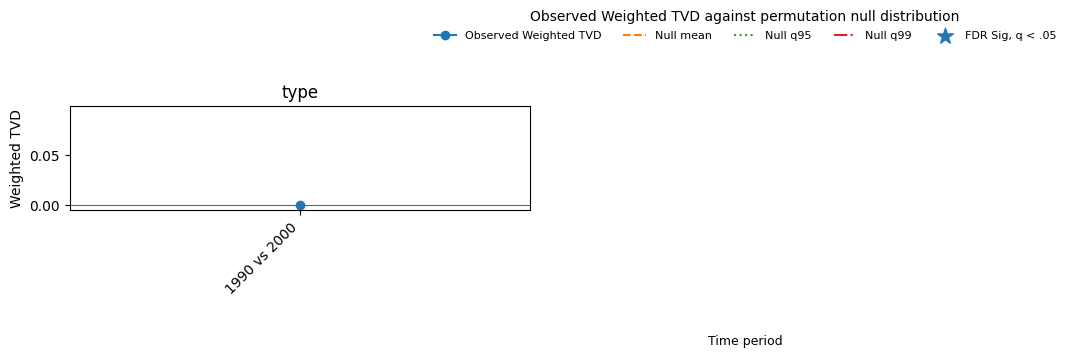

In [143]:
plot_permutation_test_consecutive_dist(perm_result_df)

In [144]:
perm_fdr_summary, corrected_SRL_period_df = summarize_fdr_correction(perm_result_df)

perm_fdr_summary
# perm_fdr_summary.to_csv(rf"{output_SCD}/SRL_type_perm_fdr_summary.csv", index=False)
perm_fdr_summary.to_csv(rf"{output_SCD}/SRLfiller_perm_fdr_summary.csv", index=False)
# corrected_SRL_period_df

In [145]:
perm_fdr_summary

,slot,total_period_tests,valid_period_tests,invalid_period_tests,raw_p_significant,fdr_significant,corrected_by_fdr,raw_significant_percent,fdr_significant_percent,fdr_corrected_percent_of_raw_sig
0,type,1,1,0,0,0,0,0.0,0.0,0


## Compute period x period distance matrix

In [146]:
period_period_dist_df = compute_period_period_dist(
    sfiller_df=SRLfiller_df,
    period_col="subfolder",
    # slot_col='chi_ARG1', # Required when the data contains multiple SRL/feature types, otherwise set to None.
    min_freq=1,
    measure="tvd",
    mode="data_only",
    weighting=True,
    k=100,
)

fig = plot_period_period_dist(period_period_dist_df)
fig.show()

Computing period-period distribution distance with measure: tvd


# Plot distance time-series

In [147]:
# Plot all SRLs on one big plot
# SRLs_to_plot = ['chi_case', 'chi_amod', 'pa_obl', 'chi_nmod', 'pa_nmod', 'pa_obj', 'chi_compound', 'pa_compound', 'pa_nsubj', 'chi_nsubj' ]  # Specify the SRLs you want to plot
# plot_all_dists_by_period(weighted_consecutive_dist_dict, layout='combined', slots=SRLs_to_plot)

# If not specified, plot everything
plot_all_dists_by_period(perm_result_df, layout="combined", col_to_plot="observed_statistic")

In [148]:
# # Plot all SRLs on one big plot
# SRLs_to_plot = ['chi_ARG0', 'chi_ARG1']  # Specify the SRLs you want to plot
# plot_all_dists_by_period(weighted_consecutive_dist, layout='combined', slots=SRLs_to_plot)

In [149]:
# Alternative: Plot as subplots in a grid
# plot_timeseries_slots(consecutive_distance_dictionary, layout='subplots')

# Alternative: Plot each SRL as a separate figure
# plot_timeseries_slots(consecutive_distance_dictionary, layout='separate')

# Save the plot to a file
# plot_timeseries_slots(consecutive_distance_dictionary, 
#                       layout='combined',
#                       save_path=f'{output_explorer}/timeseries_SRLs.png')